# 02 — Sentinel-2 Preprocessing Pipeline
### Aral Sea Water/Land Classification — AI4EO Project

This notebook prepares raw Sentinel-2 imagery for use in both supervised and unsupervised machine learning models. Raw satellite data cannot be fed directly into a model — it contains sensor artefacts, nodata regions, and values on an arbitrary uint16 scale. This pipeline resolves all of these issues and produces a clean, normalised feature stack ready for classification.

**Pipeline steps:**
1. Mount Google Drive and set paths
2. Install and import dependencies
3. Load each spectral band and apply the validity mask
4. Clip outlier reflectance values (2nd–98th percentile)
5. Normalise all bands to [0, 1] float32
6. Compute NDWI (Normalised Difference Water Index)
7. Stack all bands + NDWI into a single array `(H, W, 6)`
8. Save processed stacks to `data/processed/`
9. Produce diagnostic figures for each year

## Step 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Base path — all other paths build from this
BASE = '/content/drive/MyDrive/Claude_aral'
print(f"Base path set to: {BASE}")

Mounted at /content/drive
Base path set to: /content/drive/MyDrive/Claude_aral


## Step 2 — Install dependencies and imports

In [2]:
# rasterio is not pre-installed in Colab — install once per session
!pip install rasterio --quiet

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import rasterio
import os
from pathlib import Path

# ── Project paths ──────────────────────────────────────────────────────────
DATA_DIR      = Path(BASE) / 'data'
PROCESSED_DIR = Path(BASE) / 'data' / 'processed'
MASKS_DIR     = Path(BASE) / 'masks'
FIGURES_DIR   = Path(BASE) / 'figures'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants ──────────────────────────────────────────────────────────────
YEARS      = ['2016', '2022', '2026']
BANDS      = ['B02', 'B03', 'B04', 'B08', 'B11']
BAND_NAMES = ['Blue (B02)', 'Green (B03)', 'Red (B04)', 'NIR (B08)', 'SWIR (B11)']
CLIP_LOWER = 2    # percentile lower clip
CLIP_UPPER = 98   # percentile upper clip

print("All imports successful.")
print(f"Years to process: {YEARS}")
print(f"Bands to load:    {BANDS}")

All imports successful.
Years to process: ['2016', '2022', '2026']
Bands to load:    ['B02', 'B03', 'B04', 'B08', 'B11']


## Step 3 — Load bands and apply validity mask

Each Sentinel-2 GeoTIFF in our dataset has **two bands**:
- **Band 1**: the actual spectral reflectance values (uint16, range 0–65535)
- **Band 2**: a binary validity mask — `1` where the pixel contains real data, `0` where it is nodata (e.g. outside the satellite swath)

We take the intersection of all band validity masks to produce a single mask that is `True` only where *every* band has valid data. This ensures no partially-observed pixel ever enters the model.

In [3]:
def load_band(year: str, band: str):
    """
    Load a single Sentinel-2 band and its binary validity mask.

    Returns
    -------
    data     : float32 array (H, W) — raw reflectance
    validity : bool array   (H, W) — True where pixel is valid
    """
    path = DATA_DIR / year / f'{band}.tiff'
    with rasterio.open(path) as src:
        data     = src.read(1).astype(np.float32)
        validity = src.read(2).astype(bool)
    return data, validity

# Quick test on 2016 B03
data_test, val_test = load_band('2016', 'B03')
print(f"Band shape:       {data_test.shape}")
print(f"Data dtype:       {data_test.dtype}")
print(f"Raw value range:  [{data_test[val_test].min():.0f}, {data_test[val_test].max():.0f}]")
print(f"Valid pixels:     {val_test.sum():,} / {val_test.size:,} ({val_test.mean()*100:.1f}%)")

Band shape:       (1609, 1766)
Data dtype:       float32
Raw value range:  [0, 65535]
Valid pixels:     1,966,890 / 2,841,494 (69.2%)


## Step 4 & 5 — Percentile clipping and normalisation

Raw Sentinel-2 uint16 values span 0–65535, but a small number of pixels are saturated sensor artefacts (value exactly 65535). Without clipping, these outliers compress the dynamic range of the rest of the scene, reducing the contrast available to the model.

**Percentile clipping**: we clip to the 2nd–98th percentile of *valid* pixels, removing the top and bottom 2% of extreme values.

**Normalisation**: after clipping, we rescale linearly to [0, 1]. This puts all five spectral bands on a common scale, which is required for distance-based algorithms like K-Means and DBSCAN, and accelerates CNN convergence.

In [4]:
def clip_and_normalise(data: np.ndarray, validity: np.ndarray) -> np.ndarray:
    """
    Clip to 2nd-98th percentile of valid pixels, then rescale to [0, 1].

    Nodata pixels (validity == False) are set to 0.0 so they do not
    influence any downstream computation.
    """
    valid_pixels = data[validity]
    p_low  = np.percentile(valid_pixels, CLIP_LOWER)
    p_high = np.percentile(valid_pixels, CLIP_UPPER)

    clipped    = np.clip(data, p_low, p_high)
    normalised = (clipped - p_low) / (p_high - p_low + 1e-8)
    normalised[~validity] = 0.0

    return normalised.astype(np.float32), p_low, p_high

# Demonstrate on B03
norm_test, p2, p98 = clip_and_normalise(data_test, val_test)
print(f"Clipping range:        [{p2:.0f}, {p98:.0f}]")
print(f"Normalised value range: [{norm_test[val_test].min():.4f}, {norm_test[val_test].max():.4f}]")
print(f"Mean normalised value:  {norm_test[val_test].mean():.4f}")

Clipping range:        [2471, 27546]
Normalised value range: [0.0000, 1.0000]
Mean normalised value:  0.4622


## Step 6 — Compute NDWI

The **Normalised Difference Water Index (NDWI)** is our primary spectral discriminator between water and land:

$$NDWI = \frac{Green - NIR}{Green + NIR} = \frac{B03 - B08}{B03 + B08}$$

- **NDWI > 0** → water body (Green reflectance dominates)
- **NDWI < 0** → land, vegetation, bare soil, salt flat (NIR reflectance dominates)

Water strongly absorbs NIR radiation and reflects green wavelengths, while land and vegetation do the opposite. This physical property makes NDWI a robust water/land separator even without any machine learning — it will serve as both a standalone feature and a point of comparison against our model outputs.

In [5]:
def compute_ndwi(green_norm: np.ndarray,
                 nir_norm:   np.ndarray,
                 validity:   np.ndarray) -> np.ndarray:
    """
    Compute NDWI from normalised Green (B03) and NIR (B08) bands.

    Returns a float32 array ranging approximately [-1, 1].
    Note: NDWI is a ratio index and naturally exceeds [0,1] — this is correct.
    """
    denom = green_norm + nir_norm
    denom[denom == 0] = 1e-8        # avoid division by zero
    ndwi = (green_norm - nir_norm) / denom
    ndwi[~validity] = 0.0
    return ndwi.astype(np.float32)

# Demonstrate on 2016 data
norm_b03, _, _ = clip_and_normalise(data_test, val_test)
data_b08, val_b08 = load_band('2016', 'B08')
norm_b08, _, _ = clip_and_normalise(data_b08, val_b08)

ndwi_test = compute_ndwi(norm_b03, norm_b08, val_test & val_b08)
water_pct = (ndwi_test[val_test] > 0).mean() * 100
print(f"NDWI range:    [{ndwi_test[val_test].min():.3f}, {ndwi_test[val_test].max():.3f}]")
print(f"Water pixels (NDWI > 0): {water_pct:.1f}%")
print(f"Land pixels  (NDWI < 0): {100 - water_pct:.1f}%")

NDWI range:    [-1.000, 1.000]
Water pixels (NDWI > 0): 21.2%
Land pixels  (NDWI < 0): 78.8%


## Step 7 — Build the full feature stack

We combine all five normalised bands plus NDWI into a single array of shape `(H, W, 6)`. This is the object that every downstream script will load — unsupervised clustering, CNN training, and evaluation all read from this single processed file.

**Channel index reference:**

| Index | Channel |
|-------|---------|
| 0     | Blue (B02) |
| 1     | Green (B03) |
| 2     | Red (B04) |
| 3     | NIR (B08) |
| 4     | SWIR (B11) |
| 5     | NDWI |

In [6]:
def build_stack(year: str):
    """
    Load, preprocess, and stack all bands + NDWI for one year.

    Returns
    -------
    stack    : float32 (H, W, 6)  — normalised bands + NDWI
    validity : bool    (H, W)     — True where ALL bands are valid
    """
    print(f'\n[{year}] Building feature stack...')
    band_arrays  = []
    validity_all = None

    for band in BANDS:
        data, validity = load_band(year, band)

        # Combine validity masks — pixel must be valid in ALL bands
        validity_all = validity if validity_all is None else (validity_all & validity)

        normalised, p_low, p_high = clip_and_normalise(data, validity)
        band_arrays.append(normalised)
        print(f'  {band}: clipped [{p_low:.0f}, {p_high:.0f}] → [0, 1]')

    # NDWI: Green = index 1 (B03), NIR = index 3 (B08)
    ndwi = compute_ndwi(band_arrays[1], band_arrays[3], validity_all)
    water_pct = (ndwi[validity_all] > 0).mean() * 100
    print(f'  NDWI: {water_pct:.1f}% water pixels')

    stack = np.stack(band_arrays + [ndwi], axis=-1)
    print(f'  Stack shape: {stack.shape}, dtype: {stack.dtype}')
    print(f'  Memory:      {stack.nbytes / 1e6:.1f} MB')

    return stack, validity_all

## Step 8 — Save processed stacks to Drive

In [7]:
def save_stack(year: str, stack: np.ndarray, validity: np.ndarray):
    """Save stack and validity mask as .npy files to data/processed/."""
    stack_path    = PROCESSED_DIR / f'{year}_stack.npy'
    validity_path = PROCESSED_DIR / f'{year}_validity.npy'

    np.save(stack_path,    stack)
    np.save(validity_path, validity)

    print(f'  Saved: {stack_path}  ({stack.nbytes/1e6:.1f} MB)')
    print(f'  Saved: {validity_path}')

## Step 9 — Diagnostic figures

For each year we produce a 2-row figure:
- **Row 1**: the five normalised spectral bands
- **Row 2**: the NDWI map, true-colour RGB composite, and NDWI histogram

These figures serve as a sanity check — if preprocessing has worked correctly, the NDWI map should clearly show water as bright and land as dark, and the histogram should show a bimodal distribution with a peak below 0 (land) and a smaller peak above 0 (water).

In [8]:
def plot_diagnostics(year: str, stack: np.ndarray, validity: np.ndarray):
    """Produce and save a 2-row diagnostic figure for one year."""
    fig = plt.figure(figsize=(18, 8))
    fig.suptitle(
        f'Aral Sea — Sentinel-2 Preprocessing Diagnostics ({year})',
        fontsize=14, fontweight='bold'
    )
    gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=0.3)

    # Row 1: individual normalised bands
    cmaps = ['Blues_r', 'Greens_r', 'Reds_r', 'gray', 'hot']
    for i, (name, cmap) in enumerate(zip(BAND_NAMES, cmaps)):
        ax = fig.add_subplot(gs[0, i])
        band_img = stack[:, :, i].copy()
        band_img[~validity] = np.nan
        im = ax.imshow(band_img, cmap=cmap, vmin=0, vmax=1)
        ax.set_title(name, fontsize=9, fontweight='bold')
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Row 2 left: NDWI map
    ax_ndwi = fig.add_subplot(gs[1, 0:2])
    ndwi_img = stack[:, :, 5].copy()
    ndwi_img[~validity] = np.nan
    im = ax_ndwi.imshow(ndwi_img, cmap='RdYlBu', vmin=-0.5, vmax=0.5)
    ax_ndwi.set_title('NDWI  (blue=water, red=land)', fontsize=9, fontweight='bold')
    ax_ndwi.axis('off')
    plt.colorbar(im, ax=ax_ndwi, fraction=0.046, pad=0.04)

    # Row 2 centre: True colour RGB (B04-B03-B02)
    ax_rgb = fig.add_subplot(gs[1, 2:4])
    rgb = np.stack([stack[:, :, 2], stack[:, :, 1], stack[:, :, 0]], axis=-1)
    rgb[~validity] = 0
    ax_rgb.imshow(np.clip(rgb, 0, 1))
    ax_rgb.set_title('True colour (B04-B03-B02)', fontsize=9, fontweight='bold')
    ax_rgb.axis('off')

    # Row 2 right: NDWI histogram
    ax_hist = fig.add_subplot(gs[1, 4:6])
    ndwi_valid = stack[:, :, 5][validity]
    ax_hist.hist(ndwi_valid, bins=120, color='steelblue', edgecolor='none', alpha=0.8)
    ax_hist.axvline(0, color='red', linestyle='--', lw=1.5, label='NDWI = 0')
    water_pct = (ndwi_valid > 0).mean() * 100
    ax_hist.set_title('NDWI pixel distribution', fontsize=9, fontweight='bold')
    ax_hist.set_xlabel('NDWI value')
    ax_hist.set_ylabel('Pixel count')
    ax_hist.legend(fontsize=8)
    ax_hist.text(0.97, 0.95,
                 f'Water: {water_pct:.1f}%\nLand:  {100-water_pct:.1f}%',
                 transform=ax_hist.transAxes, ha='right', va='top', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    out_path = FIGURES_DIR / f'preprocessing_{year}.png'
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Figure saved: {out_path}')

## Run the full pipeline

The cell below runs all steps for all three years. Expected runtime in Colab: ~2–3 minutes total.


[2016] Building feature stack...


  B02: clipped [2189, 24995] → [0, 1]
  B03: clipped [2471, 27546] → [0, 1]


  B04: clipped [832, 29622] → [0, 1]
  B08: clipped [301, 31195] → [0, 1]
  B11: clipped [131, 34085] → [0, 1]
  NDWI: 21.2% water pixels
  Stack shape: (1609, 1766, 6), dtype: float32
  Memory:      68.2 MB
  Saved: /content/drive/MyDrive/Claude_aral/data/processed/2016_stack.npy  (68.2 MB)
  Saved: /content/drive/MyDrive/Claude_aral/data/processed/2016_validity.npy


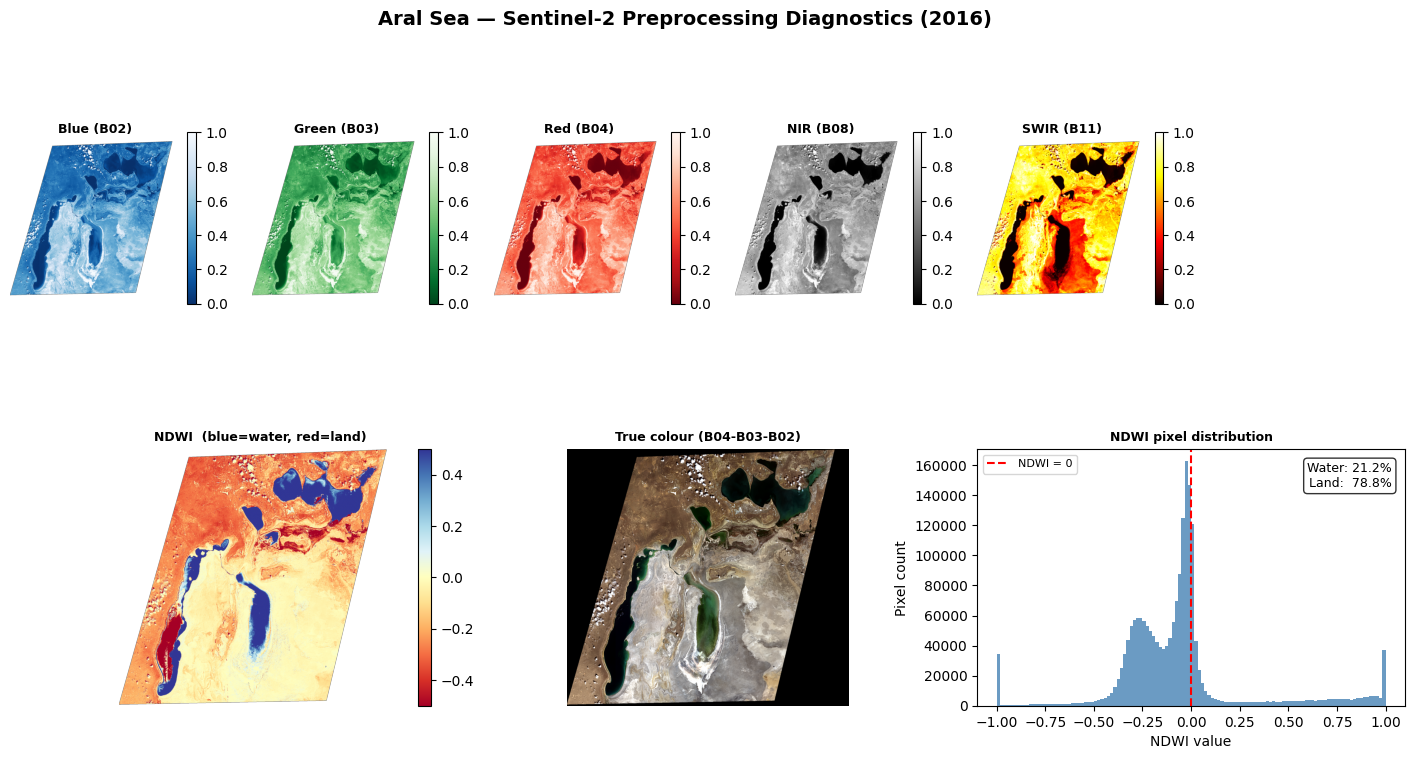

  Figure saved: /content/drive/MyDrive/Claude_aral/figures/preprocessing_2016.png

[2022] Building feature stack...


  B02: clipped [2300, 26175] → [0, 1]


  B03: clipped [2674, 29288] → [0, 1]


  B04: clipped [636, 31693] → [0, 1]


  B08: clipped [105, 34321] → [0, 1]


  B11: clipped [92, 36549] → [0, 1]
  NDWI: 15.2% water pixels
  Stack shape: (1609, 1766, 6), dtype: float32
  Memory:      68.2 MB
  Saved: /content/drive/MyDrive/Claude_aral/data/processed/2022_stack.npy  (68.2 MB)
  Saved: /content/drive/MyDrive/Claude_aral/data/processed/2022_validity.npy


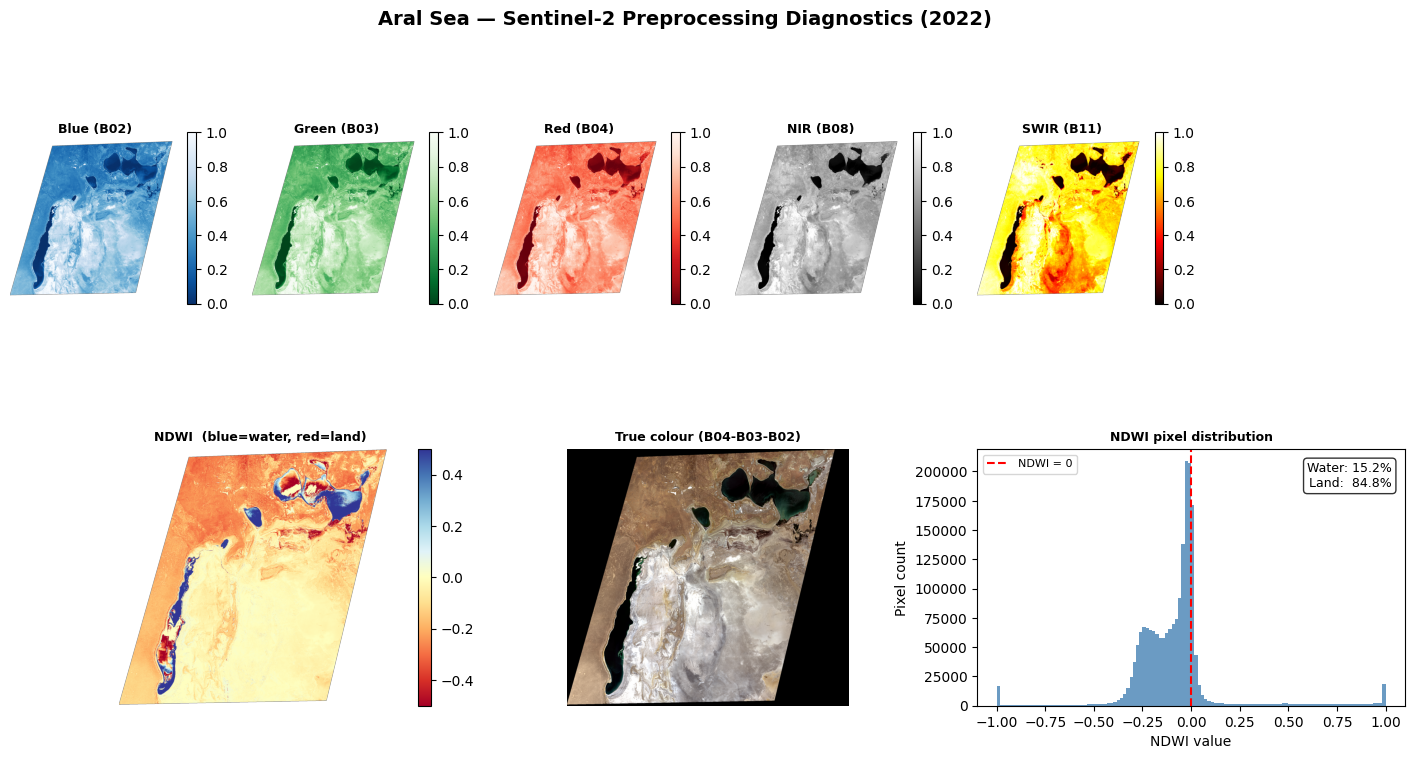

  Figure saved: /content/drive/MyDrive/Claude_aral/figures/preprocessing_2022.png

[2026] Building feature stack...


  B02: clipped [2451, 25211] → [0, 1]


  B03: clipped [2949, 28180] → [0, 1]


  B04: clipped [1003, 30140] → [0, 1]


  B08: clipped [596, 31496] → [0, 1]


  B11: clipped [623, 34019] → [0, 1]
  NDWI: 12.6% water pixels
  Stack shape: (1609, 1766, 6), dtype: float32
  Memory:      68.2 MB
  Saved: /content/drive/MyDrive/Claude_aral/data/processed/2026_stack.npy  (68.2 MB)
  Saved: /content/drive/MyDrive/Claude_aral/data/processed/2026_validity.npy


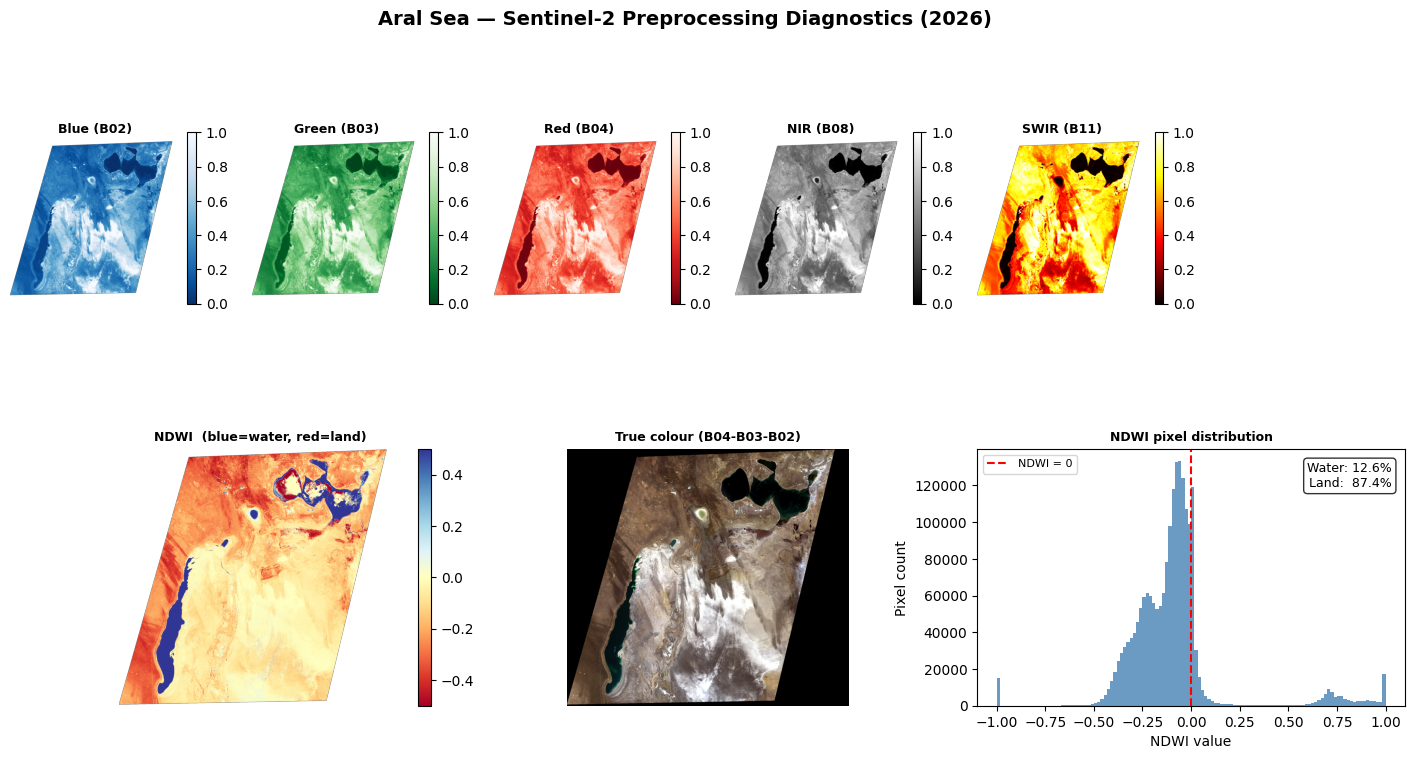

  Figure saved: /content/drive/MyDrive/Claude_aral/figures/preprocessing_2026.png

Preprocessing complete.

Channel index reference for all downstream scripts:
  stack[:, :, 0]  →  B02
  stack[:, :, 1]  →  B03
  stack[:, :, 2]  →  B04
  stack[:, :, 3]  →  B08
  stack[:, :, 4]  →  B11
  stack[:, :, 5]  →  NDWI

Files written to: /content/drive/MyDrive/Claude_aral/data/processed


In [10]:
stacks    = {}
validities = {}

for year in YEARS:
    stack, validity = build_stack(year)
    save_stack(year, stack, validity)
    plot_diagnostics(year, stack, validity)

    stacks[year]     = stack
    validities[year] = validity

print('\n' + '='*55)
print('Preprocessing complete.')
print('='*55)
print('\nChannel index reference for all downstream scripts:')
channels = BANDS + ['NDWI']
for i, ch in enumerate(channels):
    print(f'  stack[:, :, {i}]  →  {ch}')
print(f'\nFiles written to: {PROCESSED_DIR}')

## Sanity check — reload and verify

Always reload from disk and verify before moving on. This confirms the files are readable by the next notebook.

In [11]:
print('Reloading saved stacks from disk...')
for year in YEARS:
    stack_loaded    = np.load(PROCESSED_DIR / f'{year}_stack.npy')
    validity_loaded = np.load(PROCESSED_DIR / f'{year}_validity.npy')

    ndwi   = stack_loaded[:, :, 5]
    w_pct  = (ndwi[validity_loaded] > 0).mean() * 100

    print(f'  {year}: shape={stack_loaded.shape}, '
          f'dtype={stack_loaded.dtype}, '
          f'water={w_pct:.1f}%, '
          f'valid={validity_loaded.mean()*100:.1f}%')

print('\nAll stacks verified. Ready for 03_unsupervised.ipynb')

Reloading saved stacks from disk...
  2016: shape=(1609, 1766, 6), dtype=float32, water=21.2%, valid=69.2%
  2022: shape=(1609, 1766, 6), dtype=float32, water=15.2%, valid=69.2%
  2026: shape=(1609, 1766, 6), dtype=float32, water=12.6%, valid=69.2%

All stacks verified. Ready for 03_unsupervised.ipynb
